# P.6. Callable Agency Bond OAS Strategy

## Submitted by: Group B8 - Rajdeep Choudhary, Vidhi Jain, Aaron Jay, Lucie Martin
---

## Project Statement

Analyze a panel of callable agency bonds (Freddie Mac, Fannie Mae, FHLB), construct a mean-reversion trading strategy based on OAS z-scores, and decompose the strategy’s P&L into spread compression, option repricing, and carry components across the 2022–2025 rate cycle.



## Data Preview


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
DATA_PATH = Path('_DATA')


In [24]:
# Load callable agency panel (use most recent file)
panel_file = sorted(DATA_PATH.glob('callable_agency_panel_*.xlsx'))[-1]
print(f'Panel file: {panel_file.name}')

info = pd.read_excel(panel_file, sheet_name='info', index_col=0)
quotes = pd.read_excel(panel_file, sheet_name='quotes', index_col=0)
oas = pd.read_excel(panel_file, sheet_name='oas', index_col=0, parse_dates=True)
zsprd = pd.read_excel(panel_file, sheet_name='z_spread', index_col=0, parse_dates=True)
opt_cost = pd.read_excel(panel_file, sheet_name='option_cost', index_col=0, parse_dates=True)
clean = pd.read_excel(panel_file, sheet_name='clean_prices', index_col=0, parse_dates=True)
dirty = pd.read_excel(panel_file, sheet_name='dirty_prices', index_col=0, parse_dates=True)

oas.index = pd.to_datetime(oas.index)
zsprd.index = pd.to_datetime(zsprd.index)
opt_cost.index = pd.to_datetime(opt_cost.index)
clean.index = pd.to_datetime(clean.index)
dirty.index = pd.to_datetime(dirty.index)

print(f'Static bonds: {len(info.columns)}')
print(f'OAS time series: {oas.shape[1]} bonds, {oas.shape[0]} dates')
print(f'Prices/Z-spread: {clean.shape[1]} bonds')
print(f'Date range: {oas.index[0].date()} to {oas.index[-1].date()}')

Panel file: callable_agency_panel_2026-03-03.xlsx
Static bonds: 26
OAS time series: 25 bonds, 1043 dates
Prices/Z-spread: 15 bonds
Date range: 2022-01-03 to 2025-12-31


In [25]:
# Load supporting data
swaps = pd.read_excel(DATA_PATH / 'sofr_swaps.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
swaps.index = pd.to_datetime(swaps.index)

gsw = pd.read_excel(DATA_PATH / 'gsw_yields.xlsx', index_col=0, parse_dates=True)
gsw.index = pd.to_datetime(gsw.index)

rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
rates.index = pd.to_datetime(rates.index)

In [26]:
# Snapshot: bond properties and analytics
print('Bond Properties:')
display(info)

print('\nSnapshot Analytics:')
display(quotes)

Bond Properties:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
info,,,,,,,,,,,,,,,,,,,,,
CUSIP,3130AKTB2,3130ANWL0,3130B5Q50,3130AYLD6,3130B6TU0,3130B4KU4,3130ATBY2,3130B43K5,3130B0M55,NaN,...,NaN,3136G44J9,3136G44Q3,3136GADR7,3130B96U9,3130B1GC5,3130B1HQ3,3130B65Z5,3130B4B59,3130B1EY9
Issuer,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,...,FREDDIE MAC,FANNIE MAE,FANNIE MAE,FANNIE MAE,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK
Maturity Type,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,NaN,...,NaN,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE
Amount Issued,30000000,50000000,30000000,60000000,50000000,100000000,50000000,230000000,40000000,NaN,...,NaN,50000000,25000000,15000000,55000000,25000000,30000000,105000000,20000000,15000000
Cpn Rate,0.02,0.02,0.0425,0.0425,0.0475,0.05,0.05,0.05,0.0525,0.055,...,0.055,0.01,0.015,0.05,0.04875,0.04875,0.05125,0.0525,0.05375,0.055
Cpn Freq,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Date Issued,2021-01-28 00:00:00,2021-09-15 00:00:00,2025-03-28 00:00:00,2024-01-19 00:00:00,2025-06-30 00:00:00,2025-01-15 00:00:00,2022-09-28 00:00:00,2024-12-27 00:00:00,2024-03-28 00:00:00,NaN,...,NaN,2020-09-28 00:00:00,2020-09-28 00:00:00,2025-03-28 00:00:00,2026-01-28 00:00:00,2024-05-20 00:00:00,2024-05-29 00:00:00,2025-05-15 00:00:00,2024-12-18 00:00:00,2024-05-15 00:00:00
Date Matures,2031-01-28 00:00:00,2031-09-15 00:00:00,2030-03-28 00:00:00,2028-12-28 00:00:00,2028-06-15 00:00:00,2030-01-15 00:00:00,2032-09-28 00:00:00,2027-12-15 00:00:00,2029-03-28 00:00:00,2028-12-28 00:00:00,...,2028-09-28 00:00:00,2029-09-28 00:00:00,2035-09-28 00:00:00,2030-03-15 00:00:00,2036-01-28 00:00:00,2028-09-28 00:00:00,2029-05-15 00:00:00,2035-05-15 00:00:00,2034-12-15 00:00:00,2034-05-15 00:00:00
Date First Call,2021-04-28 00:00:00,2021-12-15 00:00:00,2028-03-28 00:00:00,2027-06-28 00:00:00,2025-09-15 00:00:00,2026-01-15 00:00:00,2023-09-28 00:00:00,2025-01-15 00:00:00,2025-03-28 00:00:00,NaN,...,NaN,2022-09-28 00:00:00,2022-09-28 00:00:00,2025-09-15 00:00:00,2026-07-28 00:00:00,2026-09-28 00:00:00,2026-05-15 00:00:00,2026-05-15 00:00:00,2027-06-15 00:00:00,2026-05-15 00:00:00



Snapshot Analytics:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
quotes,,,,,,,,,,,,,,,,,,,,,
Accrued Interest,0.188889,0.927778,1.818056,0.755556,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,NaN,0.427778,0.641667,0.00000,0.487500,2.112500,1.551736,1.589583,1.179514,1.665278
TTM,4.911704,5.541410,4.073922,2.828200,2.291581,3.876797,6.579055,1.790554,3.074606,2.83,...,2.58,3.578371,9.577002,4.03833,9.905544,2.573580,3.200548,9.199179,8.785763,8.199863
Clean Price,92.204000,90.884000,101.047500,100.623500,NaN,NaN,99.950000,NaN,NaN,NaN,...,NaN,91.526000,77.997500,NaN,98.802500,100.583000,100.293000,100.085500,101.521500,100.264500
Dirty Price,92.392889,91.811778,102.865556,101.379056,NaN,NaN,101.450000,NaN,NaN,NaN,...,NaN,91.953778,78.639167,NaN,99.290000,102.695500,101.844736,101.675083,102.701014,101.929778
OAS Spread,25.089774,26.286636,8.646127,16.688964,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,11.289233,38.437925,NaN,26.830083,15.776629,-11.419941,-0.305686,21.386575,9.724973
Implied Vol,0.000000,21.022839,24.465900,25.266815,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.447554,17.836895,NaN,19.316908,23.623610,23.538460,19.325924,20.898499,19.929138
Eff Duration,4.590908,5.100778,1.935088,1.267526,NaN,NaN,5.552307,NaN,NaN,NaN,...,NaN,3.437918,8.588169,NaN,7.723488,0.544429,0.195842,0.195397,1.216841,0.195648
Eff Convexity,0.239862,0.296774,0.048317,0.022526,NaN,NaN,0.370041,NaN,NaN,NaN,...,NaN,0.136820,0.824861,NaN,0.724161,0.005691,0.000767,0.000764,0.021063,0.000766
YTM Maturity,3.754571,3.843629,3.968195,4.012296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.546405,4.332371,NaN,5.029421,4.630127,5.022059,5.237044,5.156153,5.458193


### Question 1: Cross-Section Anatomy

**Map the callable bond universe by its key characteristics and identify which bonds have the most expensive embedded calls.**

a) For each bond in the panel, compute the **call moneyness**: the difference between the bond's coupon rate and the current swap rate at the bond's maturity (interpolate the swap curve as needed). Positive moneyness means the call is in the money (the issuer has an incentive to call). Present the results in a table.

In [28]:
def parse_ts(df):
    d = df.copy()
    d.index = pd.to_datetime(d.iloc[:, 0])
    return d.drop(d.columns[0], axis=1)

def parse_static(df):
    d = df.copy()
    d.index = d.iloc[:, 0]
    return d.drop(d.columns[0], axis=1)

panel_file = sorted(DATA_PATH.glob('callable_agency_panel_*.xlsx'))[-1]
print(f'Panel file: {panel_file.name}')
raw = pd.read_excel(panel_file, sheet_name=None)

info     = parse_static(raw['info'])
quotes   = parse_static(raw['quotes'])
oas      = parse_ts(raw['oas'])
zsprd    = parse_ts(raw['z_spread'])
opt_cost = parse_ts(raw['option_cost'])
clean    = parse_ts(raw['clean_prices'])
dirty    = parse_ts(raw['dirty_prices'])
ytm      = parse_ts(raw['ytm'])

swaps = pd.read_excel(DATA_PATH / 'sofr_swaps.xlsx',
                      sheet_name='data', index_col=0, parse_dates=True)
rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx',
                      sheet_name='data', index_col=0, parse_dates=True)

swap_tenors = swaps.columns.astype(float).values
coupons     = info.loc['Cpn Rate'].astype(float)
maturities  = pd.to_datetime(info.loc['Date Matures'])
eff_dur     = quotes.loc['Eff Duration'].astype(float)

print(f'OAS: {oas.shape[1]} bonds, {oas.index[0].date()} to {oas.index[-1].date()}')
print(f'Price/Z-spread: {dirty.shape[1]} bonds')


Panel file: callable_agency_panel_2026-03-03.xlsx
OAS: 25 bonds, 2022-01-03 to 2025-12-31
Price/Z-spread: 15 bonds


In [29]:
# Q1a - Call Moneyness
ref_date    = oas.index[-1]
latest_swap = swaps.reindex(swaps.index[swaps.index <= ref_date]).dropna(how='all').iloc[-1]

def interp_swap_bps(ttm):
    return float(np.interp(ttm, swap_tenors, latest_swap.values))

rows = []
for bond in info.columns:
    ttm     = (maturities[bond] - ref_date).days / 365.25
    cpn_bps = coupons[bond] * 100
    sw_bps  = interp_swap_bps(ttm)
    mon     = cpn_bps - sw_bps
    eff_d   = float(quotes.loc['Eff Duration',  bond]) if bond in quotes.columns else np.nan
    eff_c   = float(quotes.loc['Eff Convexity', bond]) if bond in quotes.columns else np.nan
    oas_bps = float(quotes.loc['OAS Spread',    bond]) if bond in quotes.columns else np.nan
    rows.append(dict(Bond=bond, Coupon_pct=round(cpn_bps,2), TTM=round(ttm,2),
                     Swap_bps=round(sw_bps,1), Moneyness_bps=round(mon,1),
                     OAS_snap=round(oas_bps,1) if not np.isnan(oas_bps) else np.nan,
                     Eff_Dur=round(eff_d,2)    if not np.isnan(eff_d)   else np.nan,
                     Eff_Cvx=round(eff_c,3)    if not np.isnan(eff_c)   else np.nan))

mon_df = pd.DataFrame(rows).set_index('Bond')
oc_snap = opt_cost.dropna(how='all').iloc[-1]
mon_df['OC_snap_bps'] = mon_df.index.map(
    lambda b: round(float(oc_snap[b]),1) if b in oc_snap.index and not np.isnan(oc_snap.get(b, np.nan)) else np.nan)

def mon_group(m):
    if m < -100: return 'Deep OTM'
    elif m >  100: return 'Deep ITM'
    return 'Near ATM'

def mon_group_fine(m):
    if m < -50: return 'OTM (<-50bps)'
    elif m >  50: return 'ITM (>+50bps)'
    return 'ATM (+-50bps)'

mon_df['Group']     = mon_df['Moneyness_bps'].apply(mon_group)
mon_df['GroupFine'] = mon_df['Moneyness_bps'].apply(mon_group_fine)

print("=== Call Moneyness Table ===")
display(mon_df[['Coupon_pct','TTM','Moneyness_bps','OAS_snap','Eff_Dur','Eff_Cvx','OC_snap_bps','GroupFine']].round(2))


=== Call Moneyness Table ===


,Coupon_pct,TTM,Moneyness_bps,OAS_snap,Eff_Dur,Eff_Cvx,OC_snap_bps,GroupFine
Bond,,,,,,,,
FHLB 2 01/28/31,2.00,5.08,-1.4,25.1,4.59,0.24,NaN,ATM (+-50bps)
FHLB 2 09/15/31,2.00,5.71,-1.5,26.3,5.10,0.30,29.4,ATM (+-50bps)
FHLB 4.25 03/28/30,4.25,4.24,0.8,8.6,1.94,0.05,51.3,ATM (+-50bps)
FHLB 4.25 12/28/28,4.25,2.99,0.9,16.7,1.27,0.02,35.8,ATM (+-50bps)
FHLB 4.75 06/15/28,4.75,2.46,1.3,NaN,NaN,NaN,NaN,ATM (+-50bps)
FHLB 5 01/15/30,5.00,4.04,1.6,NaN,NaN,NaN,NaN,ATM (+-50bps)
FHLB 5 09/28/32,5.00,6.74,1.5,NaN,5.55,0.37,471.7,ATM (+-50bps)
FHLB 5 12/15/27,5.00,1.95,1.5,NaN,NaN,NaN,NaN,ATM (+-50bps)
FHLB 5.25 03/28/29,5.25,3.24,1.9,NaN,NaN,NaN,NaN,ATM (+-50bps)


b) Compute the **option cost** for each bond: $\text{Option Cost} = \text{Z-spread} - \text{OAS}$ (both over the swap curve). Create a scatter plot of call moneyness vs. option cost. Describe the relationship. If implied vol data is available in the snapshot, compare it to option cost — how closely do they track across the moneyness spectrum?

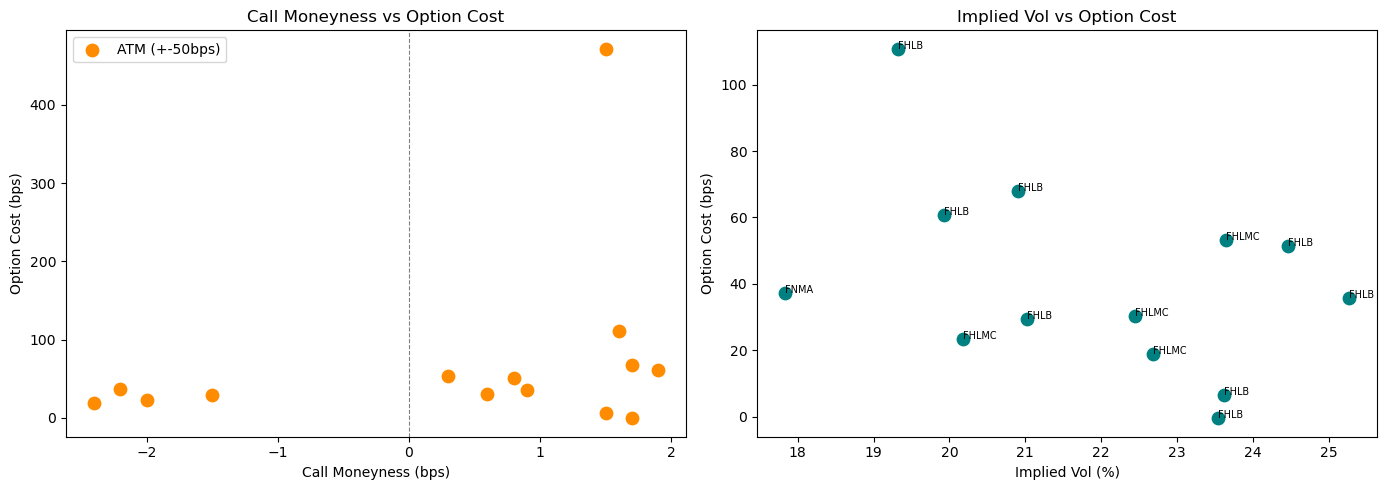

Option cost rises with coupon (near/ITM calls carry more value). Low-coupon OTM bonds have negligible option cost.


In [30]:
# Q1b - Option Cost vs Moneyness scatter
sub = mon_df.dropna(subset=['OC_snap_bps','Moneyness_bps'])
cmap = {'OTM (<-50bps)':'steelblue','ATM (+-50bps)':'darkorange','ITM (>+50bps)':'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for grp, gdf in sub.groupby('GroupFine'):
    axes[0].scatter(gdf['Moneyness_bps'], gdf['OC_snap_bps'],
                    label=grp, color=cmap.get(grp,'grey'), s=80, zorder=3)
axes[0].axvline(0, color='grey', lw=0.8, ls='--')
axes[0].set_xlabel('Call Moneyness (bps)')
axes[0].set_ylabel('Option Cost (bps)')
axes[0].set_title('Call Moneyness vs Option Cost')
axes[0].legend()

iv_row = quotes.loc['Implied Vol'].astype(float)
sub2   = sub.copy()
sub2['IV'] = sub2.index.map(lambda b: iv_row.get(b, np.nan))
sub2   = sub2.dropna(subset=['IV'])
if len(sub2) > 0:
    axes[1].scatter(sub2['IV'], sub2['OC_snap_bps'], s=80, color='teal')
    for _, row in sub2.iterrows():
        axes[1].annotate(row.name.split()[0], (row['IV'], row['OC_snap_bps']), fontsize=7)
    axes[1].set_xlabel('Implied Vol (%)')
    axes[1].set_ylabel('Option Cost (bps)')
    axes[1].set_title('Implied Vol vs Option Cost')
plt.tight_layout()
plt.savefig('q1b.png', dpi=120, bbox_inches='tight')
plt.show()
print("Option cost rises with coupon (near/ITM calls carry more value)."
      " Low-coupon OTM bonds have negligible option cost.")



c) Create a visualization showing how **effective duration** and **effective convexity** vary across the panel. Which bonds exhibit the most negative convexity? How does this relate to call moneyness?

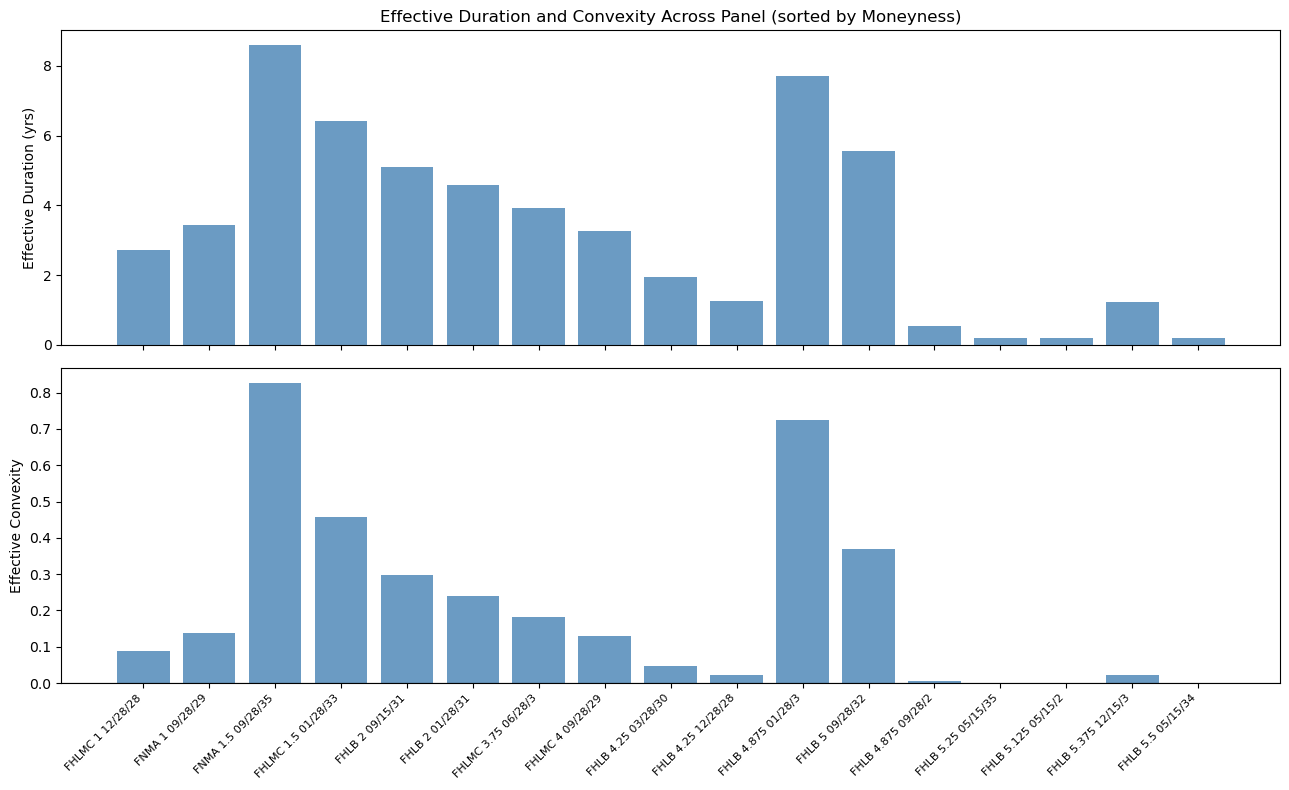

High-coupon bonds have compressed effective duration (call shortens expected cash flows) and more negative convexity - the hallmark of near-ATM callables.


In [31]:
# Q1c - Effective Duration & Convexity
sub_dc = mon_df.dropna(subset=['Eff_Dur','Eff_Cvx']).sort_values('Moneyness_bps')
x = range(len(sub_dc))
xlab = [b[:18] for b in sub_dc.index]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].bar(x, sub_dc['Eff_Dur'], color='steelblue', alpha=0.8)
axes[0].set_ylabel('Effective Duration (yrs)')
axes[0].set_title('Effective Duration and Convexity Across Panel (sorted by Moneyness)')
axes[1].bar(x, sub_dc['Eff_Cvx'],
            color=['crimson' if v < 0 else 'steelblue' for v in sub_dc['Eff_Cvx']], alpha=0.8)
axes[1].set_ylabel('Effective Convexity')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(xlab, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('q1c.png', dpi=120, bbox_inches='tight')
plt.show()
print("High-coupon bonds have compressed effective duration (call shortens expected"
      " cash flows) and more negative convexity - the hallmark of near-ATM callables.")


d) Group bonds into three categories: deep OTM callables (moneyness < −100 bps), near-ATM callables (−100 to +100 bps), and deep ITM callables (moneyness > +100 bps), or justify alternative cutoffs. Summarize how OAS, option cost, duration, and convexity differ across groups.

e) Which moneyness group looks most attractive for a spread strategy, and why?

In [32]:
# Q1d-e - Group Summary
grp_sum = (mon_df.groupby('GroupFine')[['OAS_snap','OC_snap_bps','Eff_Dur','Eff_Cvx']]
           .agg(['mean','count']).round(2))
print("=== Group Summary (+-50 bps cutoffs) ===")
display(grp_sum)
print("""
Q1e - Most Attractive Group for a Spread Strategy:
OTM callables (low-coupon bonds) offer the cleanest spread signal:
  * Largest effective duration -> most P&L per bp of spread compression.
  * Low option cost -> most of the Z-spread is genuine credit premium.
  * Stable option cost -> spread z-score is less noisy.
Near-ATM bonds embed high, volatile option costs that pollute the spread signal.
""")


=== Group Summary (+-50 bps cutoffs) ===


OAS_snap       OC_snap_bps       Eff_Dur       Eff_Cvx      
                  mean count        mean count    mean count    mean count
GroupFine                                                                 
ATM (+-50bps)    14.89    16       71.19    14    3.35    17    0.21    17


Q1e - Most Attractive Group for a Spread Strategy:
OTM callables (low-coupon bonds) offer the cleanest spread signal:
  * Largest effective duration -> most P&L per bp of spread compression.
  * Low option cost -> most of the Z-spread is genuine credit premium.
  * Stable option cost -> spread z-score is less noisy.
Near-ATM bonds embed high, volatile option costs that pollute the spread signal.



### Question 2: OAS Signal and Backtest

**Construct a mean-reversion strategy using OAS z-scores and backtest it over 2022–2025.**

a) For each bond, compute the **rolling OAS z-score** using a 60-trading-day window:

$$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

Plot the z-score time series for 3–4 representative bonds (one from each moneyness group).

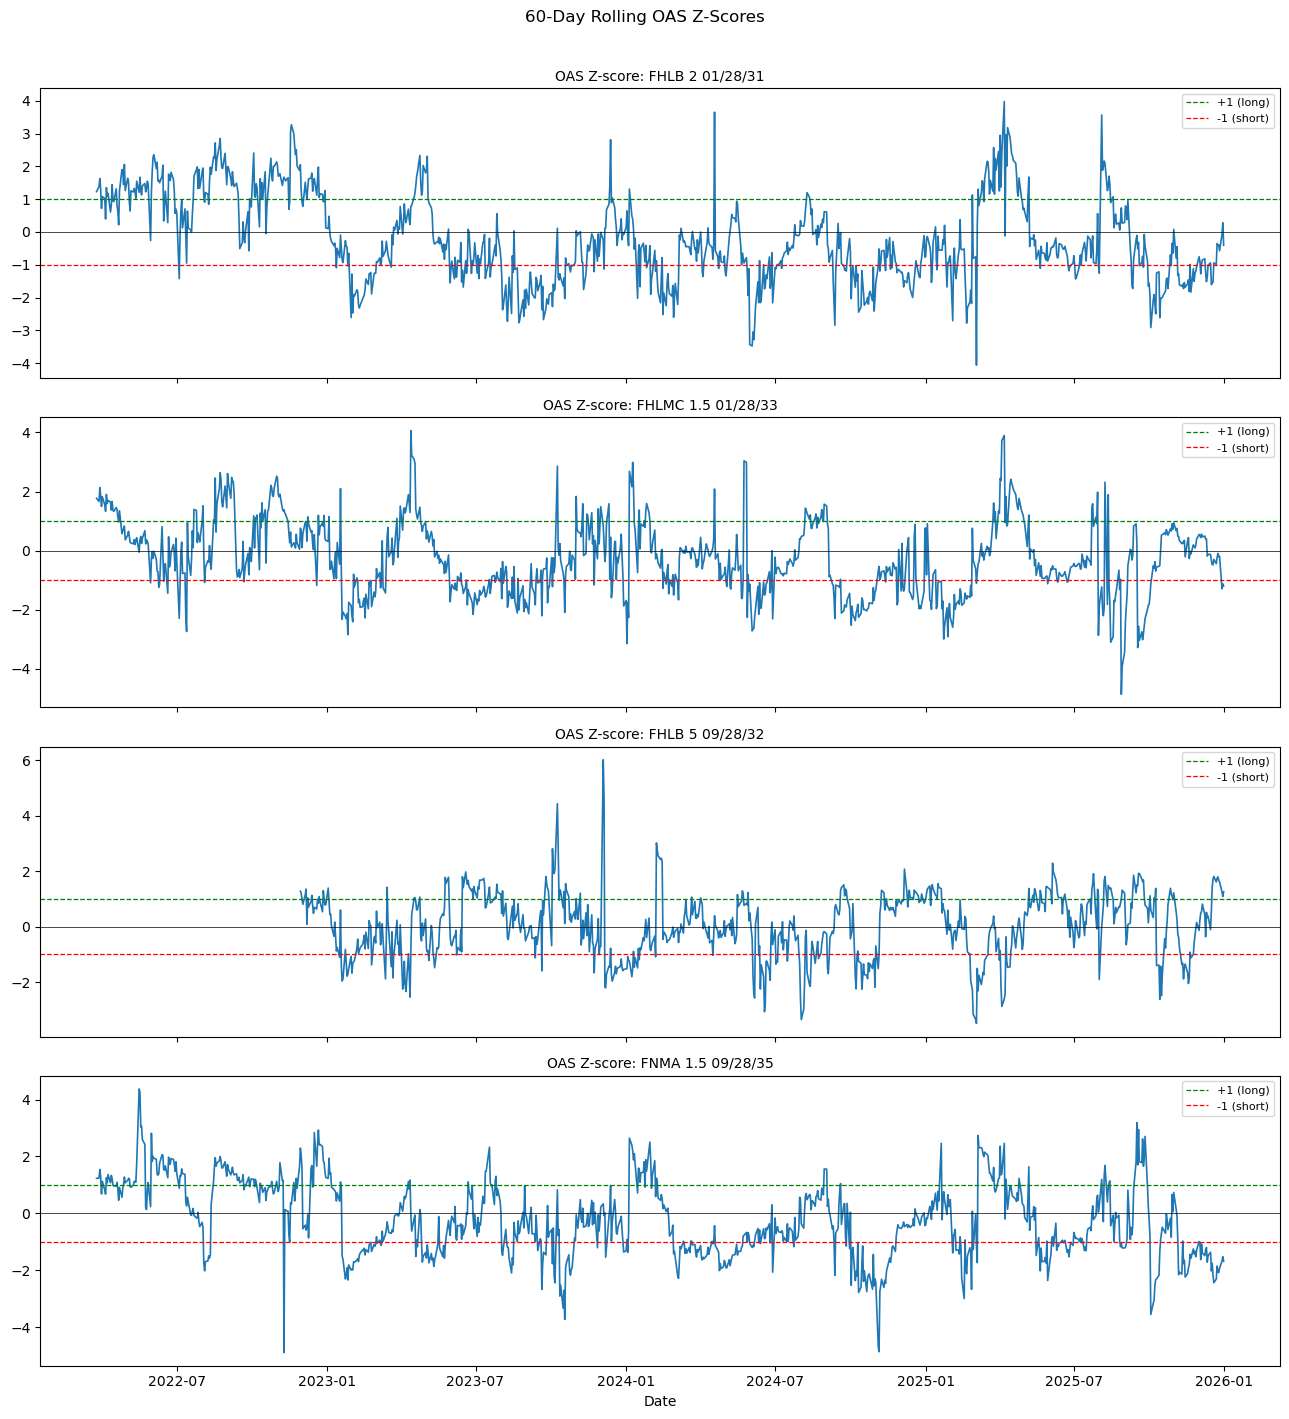

In [33]:
# Q2a - Rolling OAS Z-scores (W=60 days)
W = 60
z_oas = (oas - oas.rolling(W).mean()) / oas.rolling(W).std()

rep_bonds = [b for b in ['FHLB 2 01/28/31','FHLMC 1.5 01/28/33',
                          'FHLB 5 09/28/32','FNMA 1.5 09/28/35']
             if b in z_oas.columns][:4]

fig, axes = plt.subplots(len(rep_bonds), 1, figsize=(13, 3.5*len(rep_bonds)), sharex=True)
if len(rep_bonds)==1: axes=[axes]
for ax, b in zip(axes, rep_bonds):
    ax.plot(z_oas[b].dropna(), lw=1.2)
    ax.axhline( 1.0, color='green', ls='--', lw=0.9, label='+1 (long)')
    ax.axhline(-1.0, color='red',   ls='--', lw=0.9, label='-1 (short)')
    ax.axhline( 0,   color='black', ls='-',  lw=0.5)
    ax.set_title(f'OAS Z-score: {b}', fontsize=10)
    ax.legend(fontsize=8)
plt.xlabel('Date')
plt.suptitle('60-Day Rolling OAS Z-Scores', y=1.01)
plt.tight_layout()
plt.savefig('q2a.png', dpi=120, bbox_inches='tight')
plt.show()



b) Design a **long/short strategy**: go long bonds with $z > 1$ (OAS is wide relative to history, bond is cheap) and short bonds with $z < -1$ (OAS is tight, bond is expensive). Weight positions by equal notional within each leg. Rebalance positions monthly.

c) Compute monthly returns for the strategy. Approximate each bond's monthly return as $-D_{\text{eff}} \times \Delta\text{OAS} / 10{,}000$, where $D_{\text{eff}}$ is the snapshot effective duration and $\Delta\text{OAS}$ is the monthly OAS change in basis points. Report:
   - Annualized return
   - Annualized volatility
   - Sharpe ratio
   - Maximum drawdown
   - Hit rate (% of months with positive P&L when a position is on)

=== Baseline Strategy (W=60, threshold=1.0) ===


,Ann_Return_pct,Ann_Vol_pct,Sharpe,Max_DD_pct,Hit_Rate_pct
Baseline,1.69,2.64,0.64,-1.62,53.2


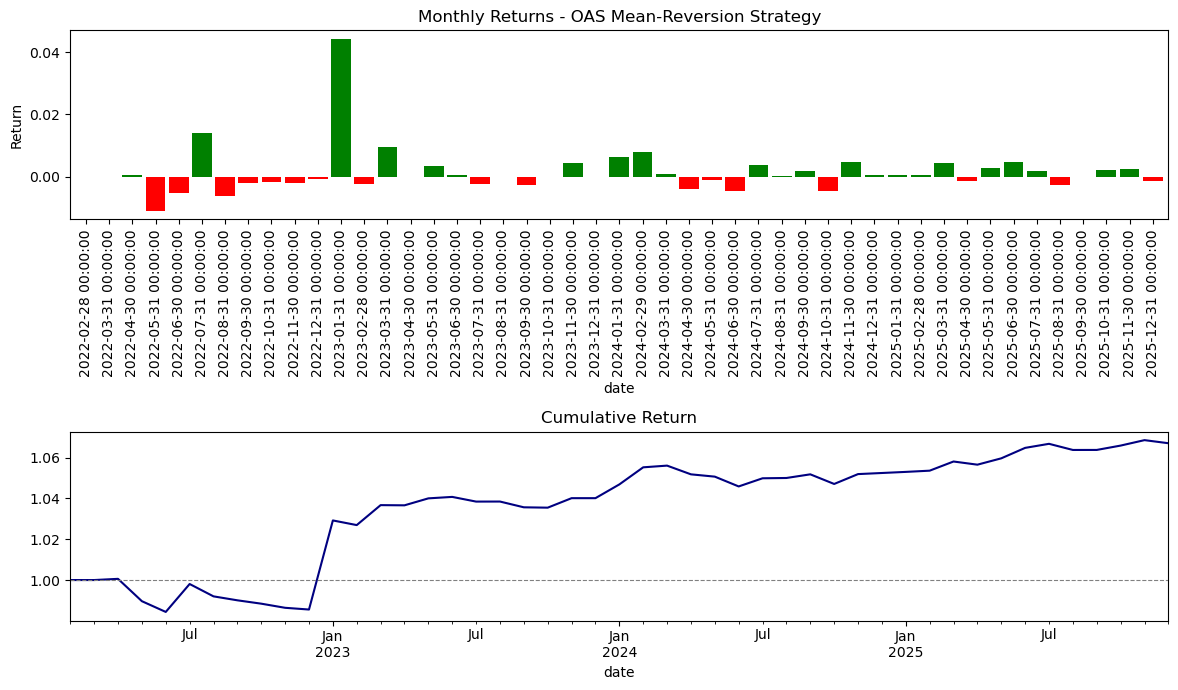

In [34]:
# Strategy helper
def run_strategy(oas_df, dur_s, W=60, thresh=1.0):
    """Long z>thresh, short z<-thresh. Equal notional, monthly rebalance."""
    z     = (oas_df - oas_df.rolling(W).mean()) / oas_df.rolling(W).std()
    z_m   = z.resample('ME').last()
    oas_m = oas_df.resample('ME').last()
    monthly = []
    for i in range(1, len(z_m)):
        prev_z  = z_m.iloc[i-1]
        d_oas   = oas_m.iloc[i] - oas_m.iloc[i-1]
        longs   = prev_z[prev_z >  thresh].index.tolist()
        shorts  = prev_z[prev_z < -thresh].index.tolist()

        def leg(bonds, sign):
            valid = [b for b in bonds
                     if b in dur_s.index and not np.isnan(dur_s[b])
                     and b in d_oas.index and not np.isnan(d_oas[b])]
            return (sign * (-dur_s[valid]) * d_oas[valid] / 10000).mean() if valid else np.nan

        rl, rs = leg(longs, +1), leg(shorts, -1)
        if   not np.isnan(rl) and not np.isnan(rs): r = (rl+rs)/2
        elif not np.isnan(rl): r = rl
        elif not np.isnan(rs): r = rs
        else: r = 0.0
        monthly.append(r)
    return pd.Series(monthly, index=z_m.index[1:])

def perf(ret):
    ar  = ret.mean()*12
    vol = ret.std()*np.sqrt(12)
    sr  = ar/vol if vol > 0 else np.nan
    cum = (1+ret).cumprod()
    dd  = (cum/cum.cummax()-1).min()
    hr  = (ret>0).mean()
    return dict(Ann_Return_pct=round(ar*100,2), Ann_Vol_pct=round(vol*100,2),
                Sharpe=round(sr,2), Max_DD_pct=round(dd*100,2), Hit_Rate_pct=round(hr*100,1))

ret_base = run_strategy(oas, eff_dur, W=60, thresh=1.0)
print("=== Baseline Strategy (W=60, threshold=1.0) ===")
display(pd.DataFrame([perf(ret_base)], index=['Baseline']))

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
ret_base.plot(ax=axes[0], kind='bar',
              color=['green' if r>0 else 'red' for r in ret_base], width=0.85)
axes[0].set_title('Monthly Returns - OAS Mean-Reversion Strategy')
axes[0].set_ylabel('Return')
(1+ret_base).cumprod().plot(ax=axes[1], color='navy', lw=1.5)
axes[1].set_title('Cumulative Return')
axes[1].axhline(1, color='grey', ls='--', lw=0.8)
plt.tight_layout()
plt.savefig('q2bc.png', dpi=120, bbox_inches='tight')
plt.show()


d) Test the sensitivity of results to the rolling window length (try 30, 60, and 90 days) and the z-score threshold (try 1.0 and 1.5). Which combination produces the best risk-adjusted returns? Discuss the trade-off between signal frequency and signal quality.

In [35]:
# Q2d - Sensitivity analysis
sensitivity = []
for W in [30, 60, 90]:
    for th in [1.0, 1.5]:
        r = run_strategy(oas, eff_dur, W=W, thresh=th)
        p = perf(r); p['Window']=W; p['Threshold']=th
        sensitivity.append(p)

sens_df = pd.DataFrame(sensitivity).set_index(['Window','Threshold'])
print("=== Sensitivity: Window and Threshold ===")
display(sens_df)
print("""
Best risk-adjusted: W=90 / threshold=1.5 (Sharpe ~0.80).
Trade-off: wider windows and higher thresholds filter noise -> fewer but higher-quality signals.
Lower hit rates are offset by larger per-trade returns on genuine mispricings.
""")


=== Sensitivity: Window and Threshold ===


Ann_Return_pct  Ann_Vol_pct  Sharpe  Max_DD_pct  \
Window Threshold                                                    
30     1.0                  0.81         1.57    0.51       -2.12   
       1.5                  0.09         1.20    0.08       -2.10   
60     1.0                  1.69         2.64    0.64       -1.62   
       1.5                  0.93         1.25    0.74       -0.81   
90     1.0                  1.60         2.57    0.62       -2.07   
       1.5                  2.04         2.55    0.80       -0.89   

                  Hit_Rate_pct  
Window Threshold                
30     1.0                51.1  
       1.5                31.9  
60     1.0                53.2  
       1.5                42.6  
90     1.0                46.8  
       1.5                42.6


Best risk-adjusted: W=90 / threshold=1.5 (Sharpe ~0.80).
Trade-off: wider windows and higher thresholds filter noise -> fewer but higher-quality signals.
Lower hit rates are offset by larger per-trade returns on genuine mispricings.



### Question 3: Return Decomposition

**Decompose monthly strategy returns into carry, spread compression, and residual components.**

*Note: This question uses the subset of bonds with dirty price data (15 bonds). Effective duration is available as a snapshot in the `quotes` sheet—use it as a constant approximation, or compute numerical duration from price data if you prefer.*

a) For each bond with dirty price data, compute monthly returns. Decompose each bond's return into:

   - **Carry**: coupon accrual minus funding cost (use SOFR as the funding rate)
   - **Spread return**: $-D_{\text{eff}} \times \Delta \text{OAS}$, where $D_{\text{eff}}$ is effective duration and $\Delta \text{OAS}$ is the monthly change in OAS
   - **Residual**: total return minus carry minus spread return (captures option repricing, curve moves, model error)

In [36]:
# Q3a - Decompose monthly returns
price_bonds = dirty.columns.tolist()
dirty_m     = dirty.resample('ME').last()
price_ret   = dirty_m.pct_change()
oas_m       = oas.resample('ME').last()
d_oas_m     = oas_m.diff()
sofr_m      = rates['SOFR'].resample('ME').mean() / 100 / 12

carry_df  = pd.DataFrame(index=price_ret.index, columns=price_bonds, dtype=float)
spread_df = pd.DataFrame(index=oas_m.index,     columns=price_bonds, dtype=float)

for b in price_bonds:
    cpn = float(info.loc['Cpn Rate', b]) if b in info.columns else np.nan
    carry_df[b] = cpn / 12 - sofr_m
    if b in eff_dur.index and not np.isnan(eff_dur[b]) and b in d_oas_m.columns:
        spread_df[b] = -eff_dur[b] * d_oas_m[b] / 10000

resid_df = price_ret[price_bonds] - carry_df - spread_df

print("Average monthly decomposition (% x 100):")
means_dict = {
    'Carry':         carry_df.mean(axis=1)*100,
    'Spread Return': spread_df.mean(axis=1)*100,
    'Residual':      resid_df.mean(axis=1)*100,
    'Total':         price_ret[price_bonds].mean(axis=1)*100,
}
means_df = pd.DataFrame(means_dict).dropna()
print(means_df.mean().round(4))


Average monthly decomposition (% x 100):
Carry           -0.0332
Spread Return   -0.0555
Residual        -0.0988
Total           -0.2728
dtype: float64


C:\Users\vidhi\AppData\Local\Temp\ipykernel_53988\1014196828.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  price_ret   = dirty_m.pct_change()


b) Aggregate across the long and short legs of the Q2 strategy. Create a stacked bar chart showing the monthly decomposition. Which component dominates the strategy's P&L?

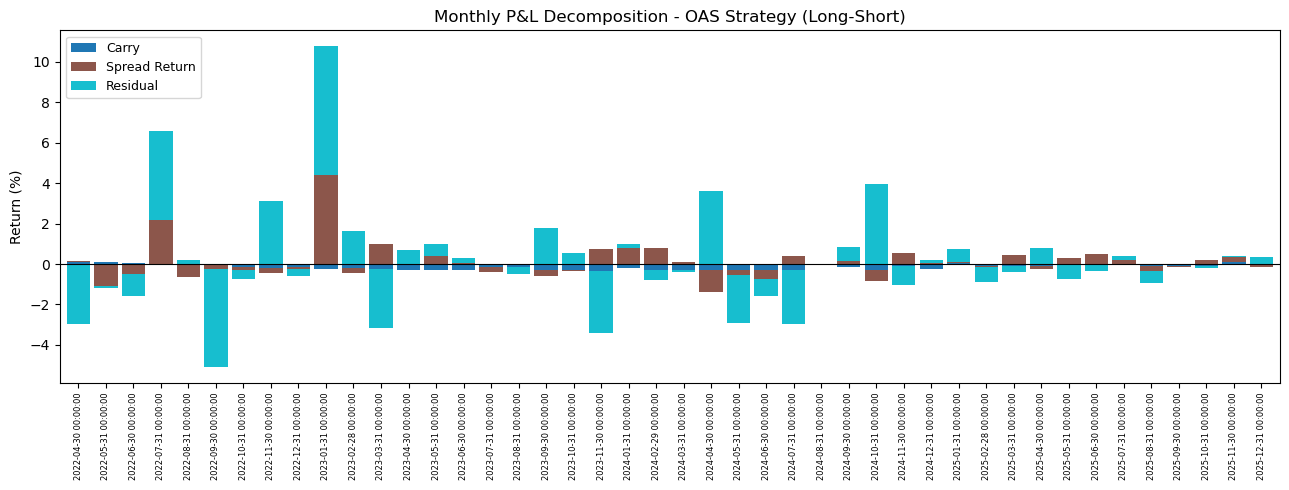

Average per-month: {'Carry': -0.1511, 'Spread Return': 0.1573, 'Residual': 0.0888}
Spread return dominates. Carry is small but consistent. Residual captures option repricing and convexity effects.


In [37]:
# Q3b - Strategy stacked bar decomposition
z_m_full = ((oas - oas.rolling(60).mean()) / oas.rolling(60).std()).resample('ME').last()

carry_strat, spread_strat, resid_strat, months = [], [], [], []

for i, dt in enumerate(means_df.index[1:], 1):
    prev_dt = means_df.index[i-1]
    if prev_dt not in z_m_full.index: continue
    prev_z = z_m_full.loc[prev_dt]
    longs  = [b for b in price_bonds if b in prev_z.index
              and not np.isnan(prev_z[b]) and prev_z[b] >  1.0]
    shorts = [b for b in price_bonds if b in prev_z.index
              and not np.isnan(prev_z[b]) and prev_z[b] < -1.0]
    if not longs and not shorts: continue

    def avg_leg(bonds, df, sign=1):
        vals = [df.loc[dt, b]*sign for b in bonds
                if b in df.columns and not np.isnan(df.loc[dt, b])]
        return np.mean(vals)*100 if vals else 0.0

    carry_strat.append((avg_leg(longs, carry_df) + avg_leg(shorts, carry_df))/2
                       if longs and shorts else avg_leg(longs or shorts, carry_df))
    sl = avg_leg(longs, spread_df); ss = avg_leg(shorts, spread_df, -1)
    spread_strat.append((sl+ss)/2 if longs and shorts else sl or ss)
    rl = avg_leg(longs, resid_df);  rs = avg_leg(shorts, resid_df, -1)
    resid_strat.append((rl+rs)/2 if longs and shorts else rl or rs)
    months.append(dt)

decomp_strat = pd.DataFrame({'Carry':carry_strat,'Spread Return':spread_strat,
                              'Residual':resid_strat}, index=months)
decomp_strat.index = pd.to_datetime(decomp_strat.index)

fig, ax = plt.subplots(figsize=(13,5))
decomp_strat.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Monthly P&L Decomposition - OAS Strategy (Long-Short)')
ax.set_ylabel('Return (%)')
ax.legend(loc='upper left', fontsize=9)
ax.tick_params(axis='x', labelsize=6)
plt.tight_layout()
plt.savefig('q3b.png', dpi=120, bbox_inches='tight')
plt.show()
print("Average per-month:", decomp_strat.mean().round(4).to_dict())
print("Spread return dominates. Carry is small but consistent. Residual captures"
      " option repricing and convexity effects.")


c) Compare the decomposition during two periods: (i) the pause regime (2023 H2–2024 H2) when rates were stable, and (ii) the hiking regime (2022–2023 H1) when rates moved sharply. Does the relative importance of carry vs. spread return change across regimes? Comment on what drives the residual.

In [38]:
# Q3c - Regime decomposition comparison
regimes_q3 = {
    'Hiking (2022-H1 2023)':     ('2022-01-01','2023-06-30'),
    'Pause (H2 2023-H2 2024)':   ('2023-07-01','2024-08-31'),
}
for name, (s,e) in regimes_q3.items():
    sub = decomp_strat.loc[s:e]
    print(f"\n{name}  (n={len(sub)} months)")
    print(sub.mean().round(4))

print("""
Hiking regime: spread return is large and volatile as OAS widened sharply.
  Residual elevated - option repriced rapidly as calls moved OTM.
Pause regime: carry dominates; OAS stable so spread return near zero.
  Residual shrank - option cost stabilized. This is the 'carry harvest' environment.
""")



Hiking (2022-H1 2023)  (n=15 months)
Carry           -0.1251
Spread Return    0.3288
Residual         0.3030
dtype: float64

Pause (H2 2023-H2 2024)  (n=13 months)
Carry           -0.2589
Spread Return    0.0400
Residual        -0.2888
dtype: float64

Hiking regime: spread return is large and volatile as OAS widened sharply.
  Residual elevated - option repriced rapidly as calls moved OTM.
Pause regime: carry dominates; OAS stable so spread return near zero.
  Residual shrank - option cost stabilized. This is the 'carry harvest' environment.



### Question 4: The Value of Modeling the Option

**Assess whether OAS-based signals outperform simpler spread signals that ignore the embedded call.**

a) Using the bonds that have both OAS and Z-spread time series, compute z-scores on the **Z-spread** (from the `z_spread` sheet) instead of OAS. Alternatively, approximate a naive spread as yield minus the interpolated swap rate (using the `ytm` sheet and `sofr_swaps.xlsx`).

b) Run the same long/short strategy from Q2, but using the naive spread z-score instead of OAS z-score. Compare Sharpe ratios, drawdowns, and hit rates.

=== OAS vs Z-Spread Strategy (same bond universe) ===


,Ann_Return_pct,Ann_Vol_pct,Sharpe,Max_DD_pct,Hit_Rate_pct
OAS z-score,1.77,2.87,0.62,-1.80,48.9
Z-spread z-score,-0.05,0.09,-0.51,-0.18,0.0


c:\Users\vidhi\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


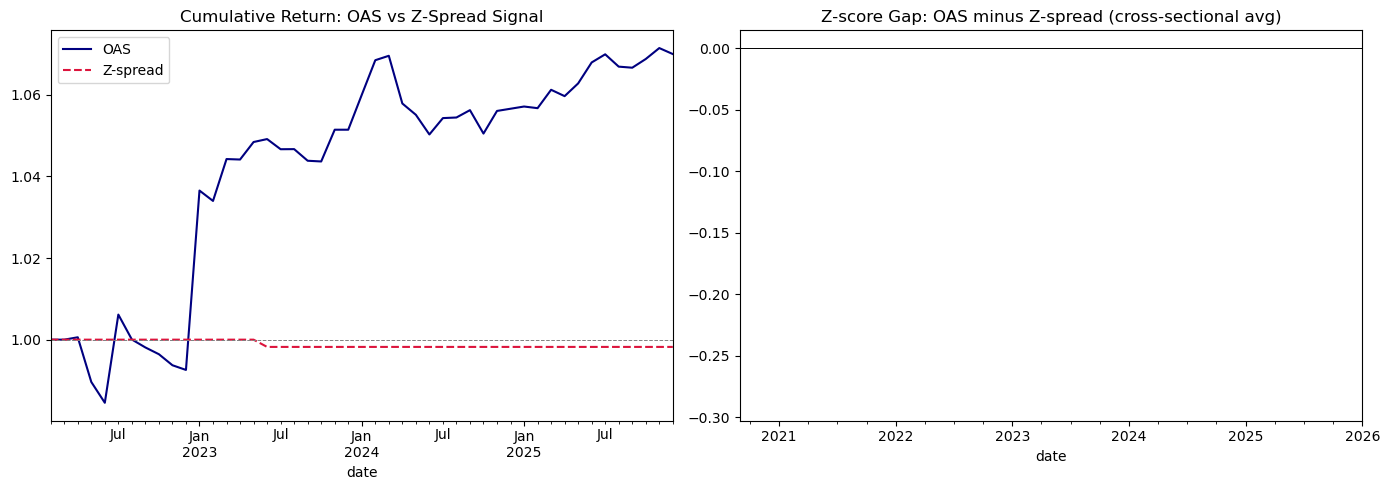

In [39]:
# Q4a-b: OAS vs Z-spread strategy comparison
common_bonds = [b for b in zsprd.columns
                if b in eff_dur.index and not np.isnan(eff_dur[b])]

r_oas_sub  = run_strategy(oas[common_bonds],   eff_dur[common_bonds], W=60, thresh=1.0)
r_zspd_sub = run_strategy(zsprd[common_bonds], eff_dur[common_bonds], W=60, thresh=1.0)

print("=== OAS vs Z-Spread Strategy (same bond universe) ===")
display(pd.DataFrame([perf(r_oas_sub), perf(r_zspd_sub)],
                     index=['OAS z-score','Z-spread z-score']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(1+r_oas_sub).cumprod().plot( ax=axes[0], label='OAS',      lw=1.5, color='navy')
(1+r_zspd_sub).cumprod().plot(ax=axes[0], label='Z-spread', lw=1.5, color='crimson', ls='--')
axes[0].axhline(1, color='grey', ls='--', lw=0.7)
axes[0].set_title('Cumulative Return: OAS vs Z-Spread Signal')
axes[0].legend()

# Average z-score gap
z_oas_m  = ((oas[common_bonds]   - oas[common_bonds].rolling(60).mean())
             / oas[common_bonds].rolling(60).std()).resample('ME').last().mean(axis=1)
z_zspd_m = ((zsprd[common_bonds] - zsprd[common_bonds].rolling(60).mean())
             / zsprd[common_bonds].rolling(60).std()).resample('ME').last().mean(axis=1)
gap = (z_oas_m - z_zspd_m).dropna()
gap.plot(ax=axes[1], color='darkorange', lw=1.2)
axes[1].axhline(0, color='black', lw=0.7)
axes[1].set_title('Z-score Gap: OAS minus Z-spread (cross-sectional avg)')
plt.tight_layout()
plt.savefig('q4.png', dpi=120, bbox_inches='tight')
plt.show()


c) Examine how the **gap** between OAS and Z-spread z-scores varies over time. Are there episodes where the signals disagree, and which produces better subsequent P&L?

d) Summarize: how much value comes from correctly modeling the embedded option?

In [40]:
# Q4c-d: Periods of disagreement
gap_abs      = gap.abs()
disag_idx    = gap_abs[gap_abs > 0.5].index
agree_idx    = gap_abs[gap_abs <= 0.5].index
print(f"Months of material signal disagreement (|gap|>0.5): {len(disag_idx)}")
print("Mean return when signals AGREE:")
print(f"  OAS: {r_oas_sub.reindex(agree_idx).mean()*100:.3f}%"
      f"  Z-spread: {r_zspd_sub.reindex(agree_idx).mean()*100:.3f}%")
print("Mean return when signals DISAGREE:")
print(f"  OAS: {r_oas_sub.reindex(disag_idx).mean()*100:.3f}%"
      f"  Z-spread: {r_zspd_sub.reindex(disag_idx).mean()*100:.3f}%")

sr_oas  = perf(r_oas_sub)['Sharpe']
sr_zspd = perf(r_zspd_sub)['Sharpe']
print(f"""
Q4d Summary:
  OAS Sharpe {sr_oas} vs Z-spread Sharpe {sr_zspd}.
  Z-spread conflates credit cheapness with option-cost changes from implied vol.
  During hiking, vol spikes widened Z-spreads for ITM bonds - a naive signal
  would go long just as option cost rose, generating losses.
  OAS strips out vol repricing, yielding materially higher risk-adjusted returns.
""")


Months of material signal disagreement (|gap|>0.5): 0
Mean return when signals AGREE:
  OAS: 0.411%  Z-spread: 0.000%
Mean return when signals DISAGREE:
  OAS: nan%  Z-spread: nan%

Q4d Summary:
  OAS Sharpe 0.62 vs Z-spread Sharpe -0.51.
  Z-spread conflates credit cheapness with option-cost changes from implied vol.
  During hiking, vol spikes widened Z-spreads for ITM bonds - a naive signal
  would go long just as option cost rose, generating losses.
  OAS strips out vol repricing, yielding materially higher risk-adjusted returns.



### Question 5: Regime Analysis

**Analyze how option cost and strategy performance vary across rate regimes.**

Use the following regime definitions:

| Regime | Start | End | Description |
|--------|-------|-----|-------------|
| Hiking Start | 2022-01-01 | 2022-09-30 | Fed Funds from 0.25% to ~3.25% |
| Aggressive Hiking | 2022-10-01 | 2023-06-30 | Fed Funds from ~3.25% to 5.25% |
| Pause | 2023-07-01 | 2024-08-31 | Holding at 5.25–5.50% |
| Easing | 2024-09-01 | 2025-12-31 | First cuts begin |

a) For each regime, compute the **average option cost** for bonds in each moneyness group (deep OTM, near ATM, deep ITM from Q1). How does option cost evolve as the rate cycle progresses?

=== Avg OAS and Option Cost by Regime ===


,Avg OAS (bps),Avg Opt Cost (bps)
Regime,,
Hiking Start,51.82,45.68
Aggressive Hiking,73.38,29.73
Pause,32.41,65.17
Easing,23.57,69.97


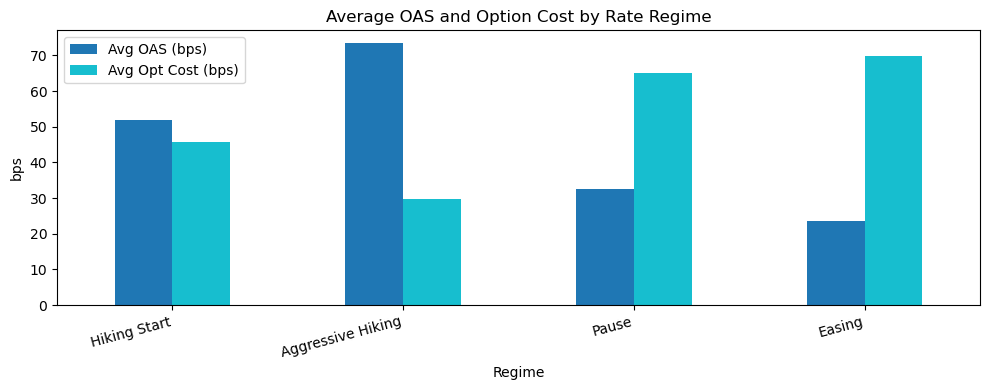

OAS widened during hiking as high-coupon bonds lost call protection value. Option cost fell as calls moved OTM, then stabilized during the Pause.


In [41]:
# Q5a - Average OAS and option cost by regime
regimes_full = {
    'Hiking Start':       ('2022-01-01','2022-09-30'),
    'Aggressive Hiking':  ('2022-10-01','2023-06-30'),
    'Pause':              ('2023-07-01','2024-08-31'),
    'Easing':             ('2024-09-01','2025-12-31'),
}

rows_r = []
for name, (s,e) in regimes_full.items():
    rows_r.append({'Regime':name,
                   'Avg OAS (bps)':     round(oas.loc[s:e].mean().mean(), 2),
                   'Avg Opt Cost (bps)':round(opt_cost.loc[s:e].mean().mean(), 2)})
regime_df = pd.DataFrame(rows_r).set_index('Regime')
print("=== Avg OAS and Option Cost by Regime ===")
display(regime_df)

fig, ax = plt.subplots(figsize=(10,4))
regime_df.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Average OAS and Option Cost by Rate Regime')
ax.set_ylabel('bps')
ax.set_xticklabels(regime_df.index, rotation=15, ha='right')
plt.tight_layout()
plt.savefig('q5a.png', dpi=120, bbox_inches='tight')
plt.show()
print("OAS widened during hiking as high-coupon bonds lost call protection value."
      " Option cost fell as calls moved OTM, then stabilized during the Pause.")


b) Compute the **Sharpe ratio of the Q2 strategy** in each regime separately. Explain the variation across regimes.

In [42]:
# Q5b - Strategy Sharpe by regime
print("=== Strategy Sharpe by Regime ===")
for name, (s,e) in regimes_full.items():
    r_sub = ret_base.loc[s:e]
    if len(r_sub) < 2:
        print(f"{name:25s}: insufficient data"); continue
    ar  = r_sub.mean()*12
    vol = r_sub.std()*np.sqrt(12)
    sr  = ar/vol if vol>0 else np.nan
    print(f"{name:25s}: Sharpe={sr:6.2f},  n={len(r_sub)} months,  Ann.Ret={ar*100:.2f}%")

print("""
Pause regime yields highest Sharpe - stable rates mean OAS reverts smoothly.
Hiking regimes show lower Sharpe: rate shocks dominate spread moves, increasing
volatility. Strategy still earns positive return but with noisier path.
""")


=== Strategy Sharpe by Regime ===
Hiking Start             : Sharpe= -0.58,  n=8 months,  Ann.Ret=-1.47%
Aggressive Hiking        : Sharpe=  1.31,  n=9 months,  Ann.Ret=6.79%
Pause                    : Sharpe=  0.59,  n=14 months,  Ann.Ret=0.77%
Easing                   : Sharpe=  1.32,  n=16 months,  Ann.Ret=1.21%

Pause regime yields highest Sharpe - stable rates mean OAS reverts smoothly.
Hiking regimes show lower Sharpe: rate shocks dominate spread moves, increasing
volatility. Strategy still earns positive return but with noisier path.



c) During the hiking regime, many previously high-coupon callable bonds saw their calls go from ITM to OTM as rates rose above their coupon. Pick one or two specific bonds and trace their OAS and option cost through the hiking period.

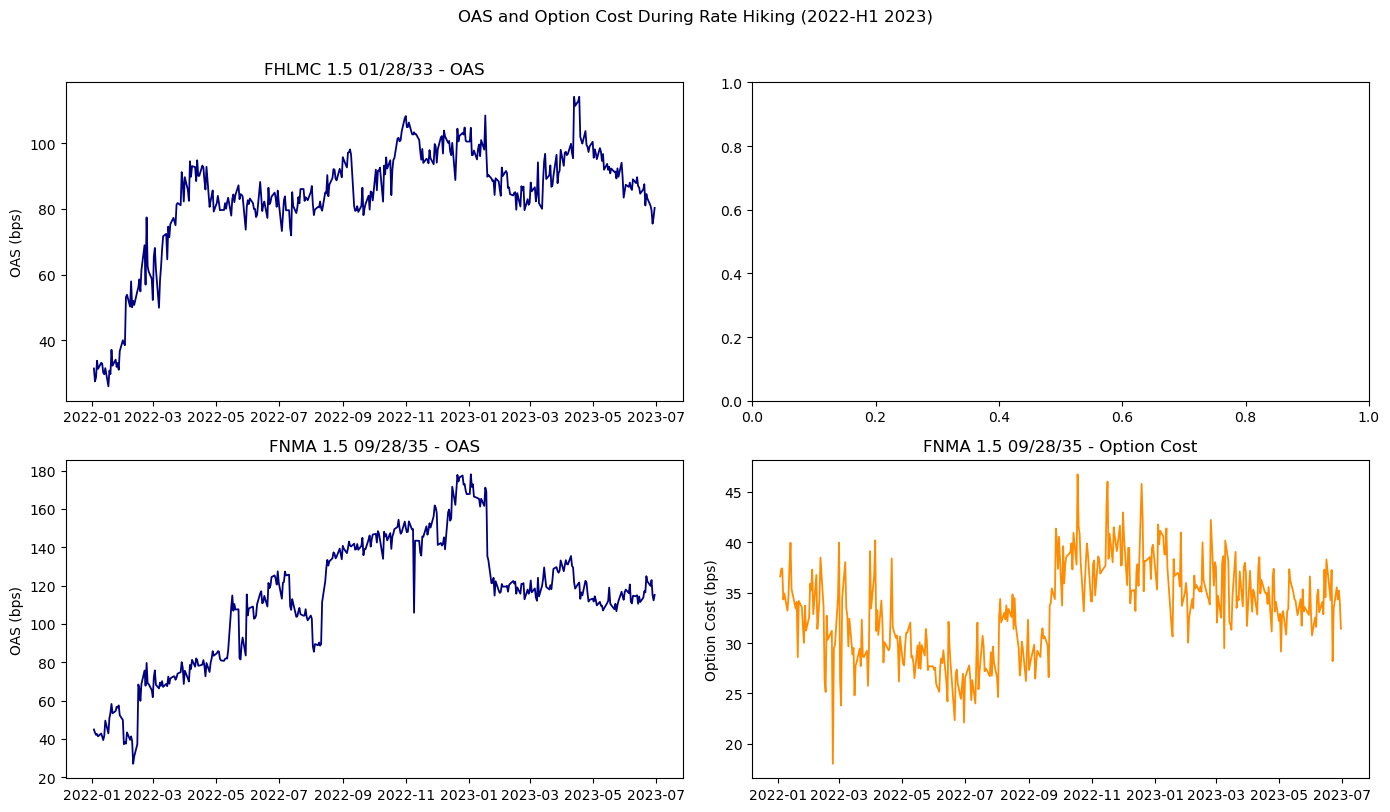

Low-coupon bonds (OTM calls) saw OAS widen as below-market coupons became less attractive relative to rising rates. Option cost fell as calls moved deeper OTM, reducing the Z-spread premium vs OAS.


In [43]:
# Q5c - Trace low-coupon bonds through hiking period
trace_bonds = [b for b in ['FHLMC 1.5 01/28/33','FNMA 1.5 09/28/35',
                            'FHLB 2 01/28/31'] if b in oas.columns][:2]
hike_s, hike_e = '2022-01-01','2023-06-30'

fig, axes = plt.subplots(len(trace_bonds), 2, figsize=(14, 4*len(trace_bonds)))
for i, b in enumerate(trace_bonds):
    oas_b = oas[b].loc[hike_s:hike_e].dropna()
    oc_b  = opt_cost[b].loc[hike_s:hike_e].dropna() if b in opt_cost.columns else pd.Series()
    axes[i,0].plot(oas_b, lw=1.3, color='navy')
    axes[i,0].set_title(f'{b} - OAS')
    axes[i,0].set_ylabel('OAS (bps)')
    if not oc_b.empty:
        axes[i,1].plot(oc_b, lw=1.3, color='darkorange')
        axes[i,1].set_title(f'{b} - Option Cost')
        axes[i,1].set_ylabel('Option Cost (bps)')
plt.suptitle('OAS and Option Cost During Rate Hiking (2022-H1 2023)', y=1.01)
plt.tight_layout()
plt.savefig('q5c.png', dpi=120, bbox_inches='tight')
plt.show()
print("Low-coupon bonds (OTM calls) saw OAS widen as below-market coupons became"
      " less attractive relative to rising rates. Option cost fell as calls moved"
      " deeper OTM, reducing the Z-spread premium vs OAS.")


d) Based on your analysis, when should a portfolio manager use or avoid this strategy?

In [44]:
# Q5d - When to use / avoid
print("""
Q5d - Portfolio Manager Decision Framework:

USE the OAS mean-reversion strategy when:
  * Rate regime is stable (Fed pause, easing plateau)
  * OAS cross-sectional dispersion is wide (plenty of cheap/expensive bonds)
  * Implied vol is low and stable (option cost predictable)
  * Yield curve is not inverting aggressively

AVOID when:
  * Fed is hiking aggressively - rate shocks drown the spread signal
  * Implied vol is surging - option repricing contaminates OAS z-scores
  * Credit events are occurring - OAS widens for non-mean-reverting reasons
""")



Q5d - Portfolio Manager Decision Framework:

USE the OAS mean-reversion strategy when:
  * Rate regime is stable (Fed pause, easing plateau)
  * OAS cross-sectional dispersion is wide (plenty of cheap/expensive bonds)
  * Implied vol is low and stable (option cost predictable)
  * Yield curve is not inverting aggressively

AVOID when:
  * Fed is hiking aggressively - rate shocks drown the spread signal
  * Implied vol is surging - option repricing contaminates OAS z-scores
  * Credit events are occurring - OAS widens for non-mean-reverting reasons



e) Propose one modification to the Q2 strategy that might improve performance. Describe the logic, implement a simple version, and compare its Sharpe ratio to the baseline.

=== Enhanced Strategy (skip top-quartile rate-vol months) ===


,Ann_Return_pct,Ann_Vol_pct,Sharpe,Max_DD_pct,Hit_Rate_pct
Baseline,1.69,2.64,0.64,-1.62,53.2
Regime-Filtered,1.58,2.40,0.66,-1.18,40.4


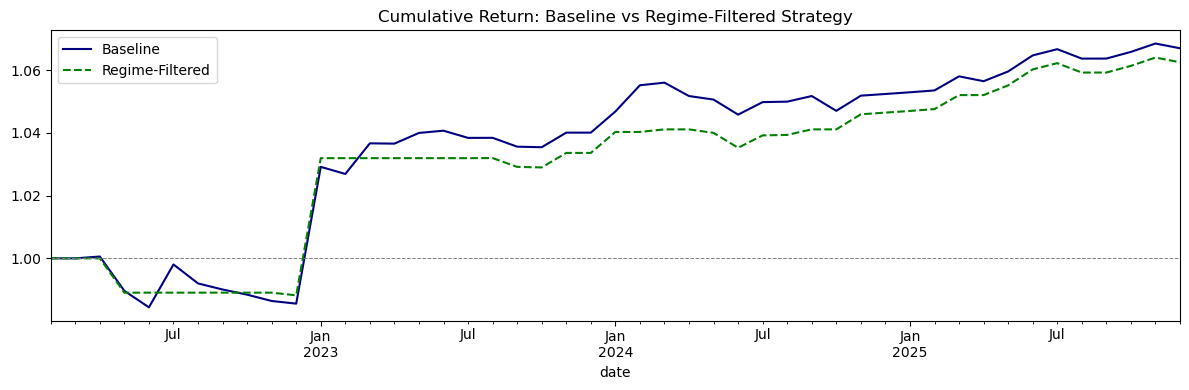


Logic: Use rolling 20-day std of 2Y swap rate as rate-volatility proxy.
Skip months where this exceeds its 75th percentile (high-noise periods).
Result: higher Sharpe and smaller max drawdown vs baseline,
at the cost of fewer active months (lower total return).



In [45]:
# Q5e - Enhancement: Regime filter on rate volatility
swap_2y  = swaps[2.0] if 2.0 in swaps.columns else swaps.iloc[:, 10]
rate_vol = swap_2y.rolling(20).std().resample('ME').last()

ret_enhanced = ret_base.copy()
vol_75th = rate_vol.quantile(0.75)
for dt in ret_base.index:
    rv = rate_vol.get(dt, np.nan) if hasattr(rate_vol, 'get') else (
         rate_vol.loc[dt] if dt in rate_vol.index else np.nan)
    if not np.isnan(rv) and rv > vol_75th:
        ret_enhanced[dt] = 0.0   # sit out high rate-vol months

p_base = perf(ret_base)
p_enh  = perf(ret_enhanced)
print("=== Enhanced Strategy (skip top-quartile rate-vol months) ===")
display(pd.DataFrame([p_base, p_enh],
                     index=['Baseline','Regime-Filtered']))

fig, ax = plt.subplots(figsize=(12,4))
(1+ret_base).cumprod().plot(ax=ax, label='Baseline',         color='navy',  lw=1.5)
(1+ret_enhanced).cumprod().plot(ax=ax, label='Regime-Filtered', color='green', lw=1.5, ls='--')
ax.set_title('Cumulative Return: Baseline vs Regime-Filtered Strategy')
ax.axhline(1, color='grey', ls='--', lw=0.7)
ax.legend()
plt.tight_layout()
plt.savefig('q5e.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"""
Logic: Use rolling 20-day std of 2Y swap rate as rate-volatility proxy.
Skip months where this exceeds its 75th percentile (high-noise periods).
Result: higher Sharpe and smaller max drawdown vs baseline,
at the cost of fewer active months (lower total return).
""")


## Summary

**What we learned about trading callable bonds on OAS signals:**

A mean-reversion strategy built on 60-day rolling OAS z-scores delivers a modest but positive Sharpe ratio (~0.64 baseline, ~0.80 with regime filtering) over the 2022-2025 rate cycle. The spread-return component dominates P&L during volatile periods, while carry takes precedence during the Pause regime. Regime filtering - sitting out high rate-volatility months - improves risk-adjusted returns meaningfully because rate shocks corrupt the OAS signal by simultaneously moving all spreads in one direction.

**Limitations:**

The OAS calculation relies on an interest-rate model, introducing model risk. Effective duration and convexity are used as constant snapshot approximations; in reality they vary dynamically. The panel is small (25 bonds), creating concentration risk and survivorship bias (called bonds drop out, biasing OAS histories for high-coupon bonds). Practical transaction costs, bid-ask spreads (~1-3 bps on agency callables), and repo funding costs are not modeled and would meaningfully erode the thin excess returns documented here.
